# Figure 4 — Representation probe: v7 vs v10 (matched protocol)

Validating the foundation representation and motivating the recipe upgrade. A source-centered
probe predicts each band's per-source brightness from the frozen bottleneck features at detected
source positions (spatial hold-out): open dot = linear ridge probe, filled dot = nonlinear MLP
probe, line = nonlinear gain. The same **identical** protocol is run on the **v7** (0.8"/px
mixed-res) and **v10** (0.4"/px fine-scale) checkpoints (a frozen probe on all compared
checkpoints, note 4 of nb05), so the scores are directly comparable.

In v7 the deep Euclid bands are only weakly and nonlinearly encoded (NISP J: linear R²=0.12); in
v10 they become strongly and **linearly** decodable (J: 0.84). Probe set: 6 tiles, ~100-120
sources (small N; noisy linear values such as v7 z are scatter).

Data: `io/_nb13_outputs/cross_instrument_summary_v7_matched.json` and `_v10_matched.json`
(regenerate with scratchpad `run_probe_v7_v10.py`). Saves `paper/figures/fig4_probe.png`.

In [1]:
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
NB = REPO / 'io' / '_nb13_outputs'
v7  = json.load(open(NB / 'cross_instrument_summary_v7_matched.json'))
v10 = json.load(open(NB / 'cross_instrument_summary_v10_matched.json'))

BANDS = ['rubin_u','rubin_g','rubin_r','rubin_i','rubin_z','rubin_y',
         'euclid_VIS','euclid_Y','euclid_J','euclid_H']
LABELS = ['u','g','r','i','z','y','VIS','Y','J','H']
def vecs(d):
    return (np.array([d['diag2b_source_ridge_r2'][b] for b in BANDS]),
            np.array([d['diag2b_source_mlp_r2'][b]   for b in BANDS]))
r7, m7   = vecs(v7)
r10, m10 = vecs(v10)
print('v7  Euclid ridge:', np.round(r7[6:], 2))
print('v10 Euclid ridge:', np.round(r10[6:], 2))

v7  Euclid ridge: [0.25 0.51 0.12 0.42]
v10 Euclid ridge: [0.6  0.68 0.84 0.84]


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig4_probe.png


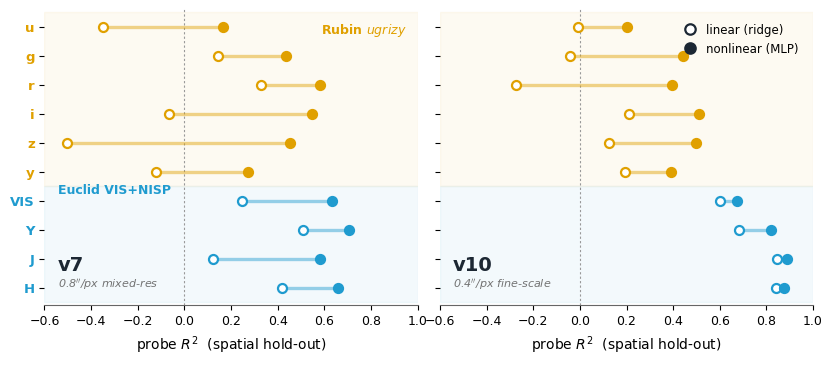

In [2]:
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'
cols = [C_RUBIN]*6 + [C_EUCLID]*4
y = np.arange(10)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5), sharey=True, sharex=True)
panels = [(axes[0], r7, m7, 'v7', '0.8$^{\\prime\\prime}$/px mixed-res'),
          (axes[1], r10, m10, 'v10', '0.4$^{\\prime\\prime}$/px fine-scale')]

for ax, ridge, mlp, tag, sub in panels:
    ax.axhspan(3.5, 9.5, color=C_RUBIN,  alpha=0.05, zorder=0)
    ax.axhspan(-0.5, 3.5, color=C_EUCLID, alpha=0.05, zorder=0)
    ax.axvline(0, color='0.6', lw=0.8, ls=(0, (2, 2)), zorder=1)
    for i in range(10):
        c = cols[i]
        ax.plot([ridge[i], mlp[i]], [y[i], y[i]], color=c, lw=2.4, alpha=0.45,
                solid_capstyle='round', zorder=2)
        ax.scatter(ridge[i], y[i], s=42, facecolor='white', edgecolor=c, lw=1.6, zorder=3)
        ax.scatter(mlp[i],   y[i], s=42, facecolor=c,       edgecolor=c, lw=1.6, zorder=3)
    ax.set_xlim(-0.6, 1.0); ax.set_ylim(-0.6, 9.6)
    ax.set_xlabel('probe $R^2$  (spatial hold-out)', fontsize=10)
    ax.tick_params(labelsize=9)
    for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color('0.4')
    # version tag in bottom-left corner of each panel (replaces top title)
    ax.text(0.035, 0.105, tag, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=14, weight='bold', color=INK)
    ax.text(0.035, 0.045, sub, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=8, color='0.45', style='italic')

axes[0].set_yticks(y); axes[0].set_yticklabels(LABELS, fontsize=9.5)
for tick, c in zip(axes[0].get_yticklabels(), cols):
    tick.set_color(c); tick.set_fontweight('bold')

# instrument group labels on left panel (Rubin top-right, Euclid mid-left)
axes[0].text(0.97, 0.96, 'Rubin $ugrizy$', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9, color=C_RUBIN, weight='bold')
axes[0].text(0.035, 0.41, 'Euclid VIS+NISP', transform=axes[0].transAxes,
             ha='left', va='top', fontsize=9, color=C_EUCLID, weight='bold')

# linear/nonlinear legend in top-right corner of the v10 panel
leg = [Line2D([0],[0], marker='o', ls='none', mfc='white', mec=INK, mew=1.6, ms=7.5, label='linear (ridge)'),
       Line2D([0],[0], marker='o', ls='none', mfc=INK,    mec=INK, mew=1.6, ms=7.5, label='nonlinear (MLP)')]
axes[1].legend(handles=leg, loc='upper right', fontsize=8.5, frameon=False,
               handletextpad=0.4, borderaxespad=0.8)

fig.subplots_adjust(wspace=0.06, left=0.075, right=0.99, top=0.98, bottom=0.135)
out = FIGDIR / 'fig4_probe.png'
fig.savefig(out, dpi=400, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()